In [17]:
import tarfile

with tarfile.open("/content/1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz", "r:gz") as tar:
    tar.extractall("common_voice_az")

/tmp/ipykernel_1431/2350319817.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("common_voice_az")


In [18]:
import os
import pandas as pd
from datasets import Dataset, Audio

DATA_DIR = "/content/common_voice_az/cv-corpus-25.0-2026-03-09/az/"
CLIPS_DIR = f"{DATA_DIR}/clips"

df = pd.read_csv(f"{DATA_DIR}/train.tsv", sep='\t')


df['audio'] = df['path'].apply(lambda p: os.path.join(CLIPS_DIR, p))

df = df[['audio', 'sentence']]

dataset = Dataset.from_pandas(df)

dataset = dataset.cast_column("audio", Audio(sampling_rate=16_000))

dataset[0]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7d2a03d3cbf0>,
 'sentence': 'Məqbərənin yaxınlığında ölməz şairin yaratdığı əsərləri tərənnüm edən tuncdan abidə yerləşir.'}

In [24]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

model.eval()

print("Device: ", device)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Device:  cuda


In [25]:
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="az",
    task='transcribe'
)

In [26]:
import re

def normalize_text(text):
    text = text.lower().strip()

    # keep Azerbaijani letters, numbers, and spaces
    text = re.sub(r"[^\w\səıöüçğş]", " ", text)

    # normalize multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


In [27]:
!pip install -q evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.6 MB/s eta 0:00:00


In [29]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
from dataclasses import dataclass
import evaluate
import pandas as pd
import matplotlib.pyplot as plt

small_dataset = dataset.shuffle(seed=42).select(range(200))

split = small_dataset.train_test_split(test_size=0.2, seed=42)

train_raw = split["train"]
valid_raw = split["test"]

In [31]:
def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["sentence"]
    ).input_ids

    return batch

In [32]:
train_ds = train_raw.map(prepare_dataset, remove_columns=train_raw.column_names)
valid_ds = valid_raw.map(prepare_dataset, remove_columns=valid_raw.column_names)

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [33]:
@dataclass
class DataCollator:
    processor: object

    def __call__(self, features):
        audio_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(audio_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels
        return batch

In [34]:
data_collator = DataCollator(processor)

In [35]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
    refs = processor.batch_decode(label_ids, skip_special_tokens=True)

    preds = [normalize_text(x) for x in preds]
    refs = [normalize_text(x) for x in refs]

    return {
        "wer": wer_metric.compute(predictions=preds, references=refs),
        "cer": cer_metric.compute(predictions=preds, references=refs),
    }

In [37]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper_az_ft",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    learning_rate=1e-5,

    predict_with_generate=True,
    generation_max_length=128,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    logging_steps=5,
    save_total_limit=1,
    report_to="none"
)

In [38]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [39]:
trainer.train()

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.960603,0.922327,1.240924,0.437325
2,0.472692,0.800003,1.211221,0.456501
3,0.307996,0.766056,1.171617,0.430309


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=120, training_loss=0.7294662366310756, metrics={'train_runtime': 499.3102, 'train_samples_per_second': 0.961, 'train_steps_per_second': 0.24, 'total_flos': 1.385209921536e+17, 'train_loss': 0.7294662366310756, 'epoch': 3.0})

In [41]:
trainer.save_model("./best_whisper_az")
processor.save_pretrained("./best_whisper_az")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./best_whisper_az/processor_config.json']

In [43]:
logs = pd.DataFrame(trainer.state.log_history)

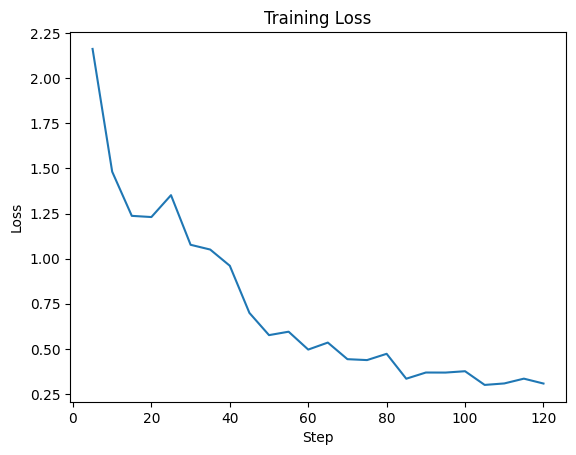

In [44]:
loss_logs = logs[logs["loss"].notna()]

plt.plot(loss_logs["step"], loss_logs["loss"])
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

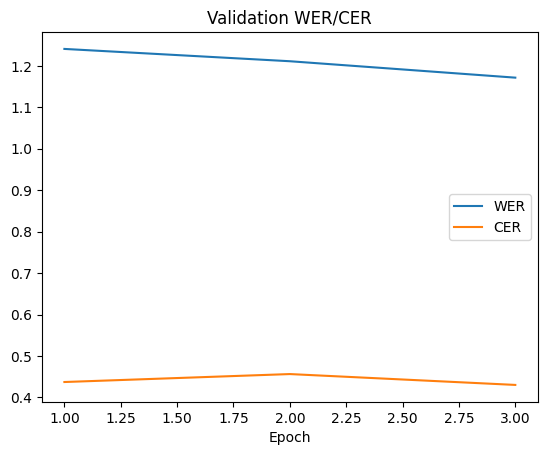

In [45]:
eval_logs = logs[logs["eval_wer"].notna()]

plt.plot(eval_logs["epoch"], eval_logs["eval_wer"], label="WER")
plt.plot(eval_logs["epoch"], eval_logs["eval_cer"], label="CER")
plt.title("Validation WER/CER")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [46]:
fine_tuned_model = WhisperForConditionalGeneration.from_pretrained("./best_whisper_az").to(device)
fine_tuned_model.eval()

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [47]:
test_samples = dataset.shuffle(seed=123).select(range(50))

In [48]:
def predict(model, data):
    preds = []
    refs = []

    for example in data:
        audio = example["audio"]

        input_features = processor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            ids = model.generate(
                input_features,
                forced_decoder_ids=forced_decoder_ids
            )

        text = processor.batch_decode(ids, skip_special_tokens=True)[0]

        preds.append(text)
        refs.append(example["sentence"])

    return preds, refs

In [49]:
base_preds, refs = predict(model, test_samples)
ft_preds, _ = predict(fine_tuned_model, test_samples)

In [50]:
refs_norm = [normalize_text(x) for x in refs]
base_norm = [normalize_text(x) for x in base_preds]
ft_norm = [normalize_text(x) for x in ft_preds]

In [51]:
comparison = pd.DataFrame([
    {
        "model": "Base Whisper",
        "WER": wer_metric.compute(predictions=base_norm, references=refs_norm),
        "CER": cer_metric.compute(predictions=base_norm, references=refs_norm),
    },
    {
        "model": "Fine-tuned Whisper",
        "WER": wer_metric.compute(predictions=ft_norm, references=refs_norm),
        "CER": cer_metric.compute(predictions=ft_norm, references=refs_norm),
    }
])

comparison

,model,WER,CER
0,Base Whisper,0.088319,0.022155
1,Fine-tuned Whisper,0.088319,0.022155


In [52]:
pd.DataFrame({
    "reference": refs,
    "base_prediction": base_preds,
    "fine_tuned_prediction": ft_preds
})

,reference,base_prediction,fine_tuned_prediction
0,Belarus milli futbol komandasına namizəd sayılır.,Belarus milli futbol komandasına namizəs sayılır.,Belarus milli futbol komandasına namizəs sayılır.
1,Ondan bir oğulu olar.,Ondan bir oğlu olar.,Ondan bir oğlu olar.
2,Yer kürəsini başqa elmlər də öyrənir.,Yer kürəsini başqa elmlər də öyrənir.,Yer kürəsini başqa elmlər də öyrənir.
3,İnqilabdan sonra asılmışdır.,İnqilabdan sonra asılmışdır.,İnqilabdan sonra asılmışdır.
4,Meşə və kolluqlarda rast gəlinir.,Meşə və kolluqlarda rast gəlinir.,Meşə və kolluqlarda rast gəlinir.
5,Bu böyük bir hadisə idi.,Bu böç bir hadis idi.,Bu böç bir hadis idi.
6,İlk illərdə aktyor bu teatrın səhnəsində müxtə...,İlk illərdə aktyor bu teatrın səhnəsində müxtə...,İlk illərdə aktyor bu teatrın səhnəsində müxtə...
7,Axund Hacı Əbdülkərim Ağanın yaradıcılığı onun...,Axund Hacı Əbdülkərim Ağanın yaradıcılığı onun...,Axund Hacı Əbdülkərim Ağanın yaradıcılığı onun...
8,Musiqi məktəbinin bütün tədbirlərində fəal işt...,Müşqi məktəbinin bütün tədbirlərində fəal işti...,Müşqi məktəbinin bütün tədbirlərində fəal işti...
9,İbtidai təhsilini mollaxanada almışdır.,İbtidai təhsilini mollaxanada almışdır.,İbtidai təhsilini mollaxanada almışdır.
